In [2]:
%matplotlib ipympl
import jupyter
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
#import skimage as ski
import warnings as warn
import pyxu.experimental.xray as pxr
import sys
import mrcfile
import tqdm
import pyxu.util as pxu
import pyxu.opt.stop as pxst
import cupy as cp
import pyxu.abc as pxa
from pyxu.opt.solver import pgd, PGD, CV
from pyxu.abc import ProxFunc
from pyxu.operator import Convolve
import matplotlib
from contrasttransferfunction import ContrastTransferFunction
import torch
from pyxu.operator.interop import from_torch
from pyxu.operator import Gradient, SquaredL2Norm, L1Norm, L21Norm, PositiveL1Norm, PositiveOrthant
from pyxu.opt.solver import PD3O
from pyxu.operator import blocks

import scipy.ndimage.interpolation as interp

In [3]:
# ========= IMOD reconstruction from Bern =========
rec_bern_file = 'Position_12_rec.mrc'
with mrcfile.open(rec_bern_file, 'r') as mrc:
    rec_bern = mrc.data # (Nangles, 1024 1024)
v_shape_bern = rec_bern.shape

In [4]:
vol_1 = np.load('rec2_TV_200.npy')
vol_2 = np.load('rec1_TV_200.npy')*1.2
#print(vol_2.shape)
vol_3 = np.load('rec3_TV_200.npy')*1.2*1.1
full_volume = np.concatenate((vol_1[:, :, :-5], vol_2, vol_3[:, :, 5:]), axis= 2)
v_shape = full_volume.shape

vol_1_pinv = np.load('rec2_pinv.npy')
div = 1.2
vol_2_pinv = np.load('rec1_pinv.npy')*div
vol_3_pinv = np.load('rec3_pinv.npy')*div*1.1
full_volume_pinv = np.concatenate((vol_1_pinv[:, :, :-30], vol_2_pinv, vol_3_pinv[:, :, 30:]), axis= 2)

In [5]:
rec_bern_downsampled = rec_bern[v_shape_bern[0]//2 +50,:,:].T[::4, ::4][:, 2:-2] / np.max(rec_bern[v_shape_bern[0]//2 +50,:,:].T[::4, ::4][:, 2:-2])
rec_pinv = full_volume_pinv[v_shape[0]//2,v_shape[1]//2-512:v_shape[1]//2+512,:]/np.max(full_volume_pinv[v_shape[0]//2,v_shape[1]//2-512:v_shape[1]//2+512,:])
rec_tv = full_volume[v_shape[0]//2,v_shape[1]//2-512:v_shape[1]//2+512,:]/np.max(full_volume[v_shape[0]//2,v_shape[1]//2-512:v_shape[1]//2+512,:])

In [43]:
rec_bern_downsampled_miss = np.flip(rec_bern[:,:,v_shape_bern[2]//2+20], axis=0)/ np.max(rec_bern[v_shape_bern[0]//2 +50,:,:].T[::4, ::4][:, 2:-2])
rec_pinv_miss = full_volume_pinv[:,v_shape[1]//2,:]/np.max(full_volume_pinv[v_shape[0]//2,v_shape[1]//2-512:v_shape[1]//2+512,:])
rec_tv_miss = full_volume[v_shape[0]//2,v_shape[1]//2-512:v_shape[1]//2+512,:]/np.max(full_volume[v_shape[0]//2,v_shape[1]//2-512:v_shape[1]//2+512,:])

In [23]:
from jupyter_compare_view import compare

(881, 4096)
(200, 960)



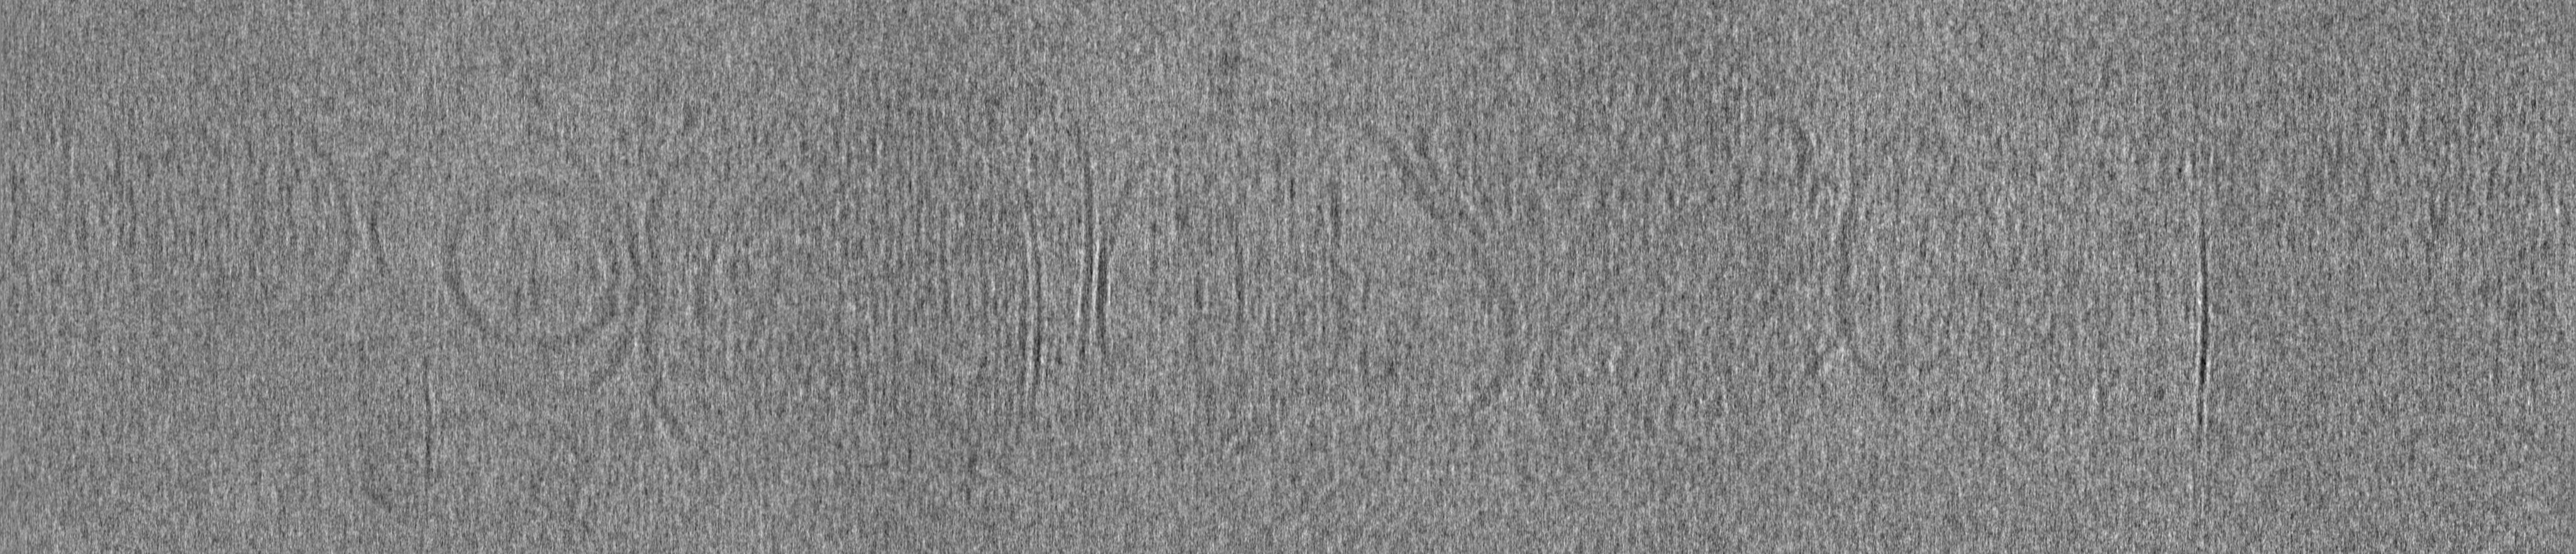
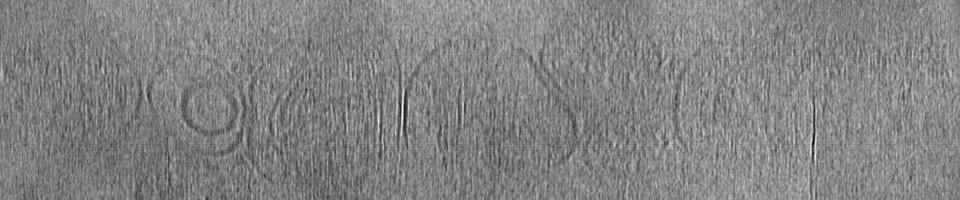

In [44]:
print(rec_bern_downsampled_miss.shape)
print(rec_pinv_miss.shape)
compare(rec_bern_downsampled_miss, rec_pinv_miss, cmap="gray", start_mode="horizontal", start_slider_pos=0.73, height=200)


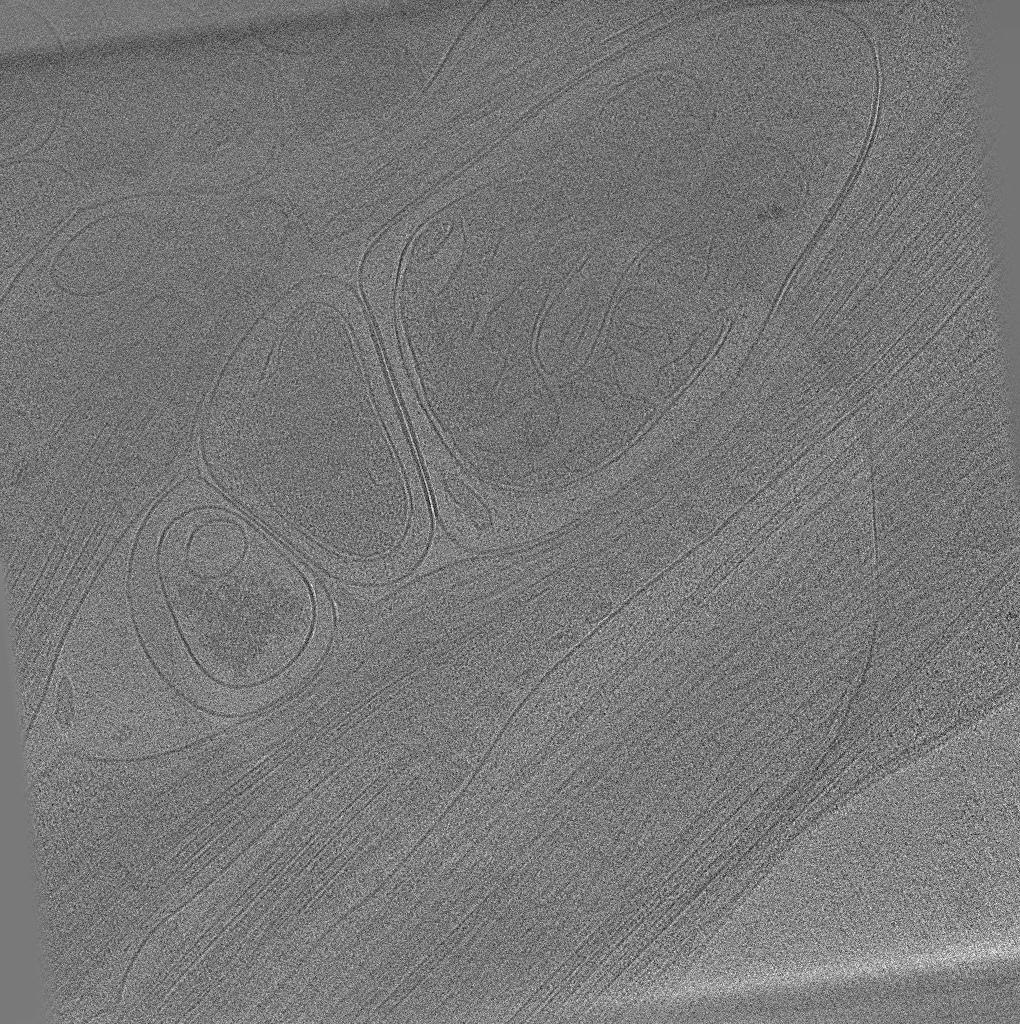
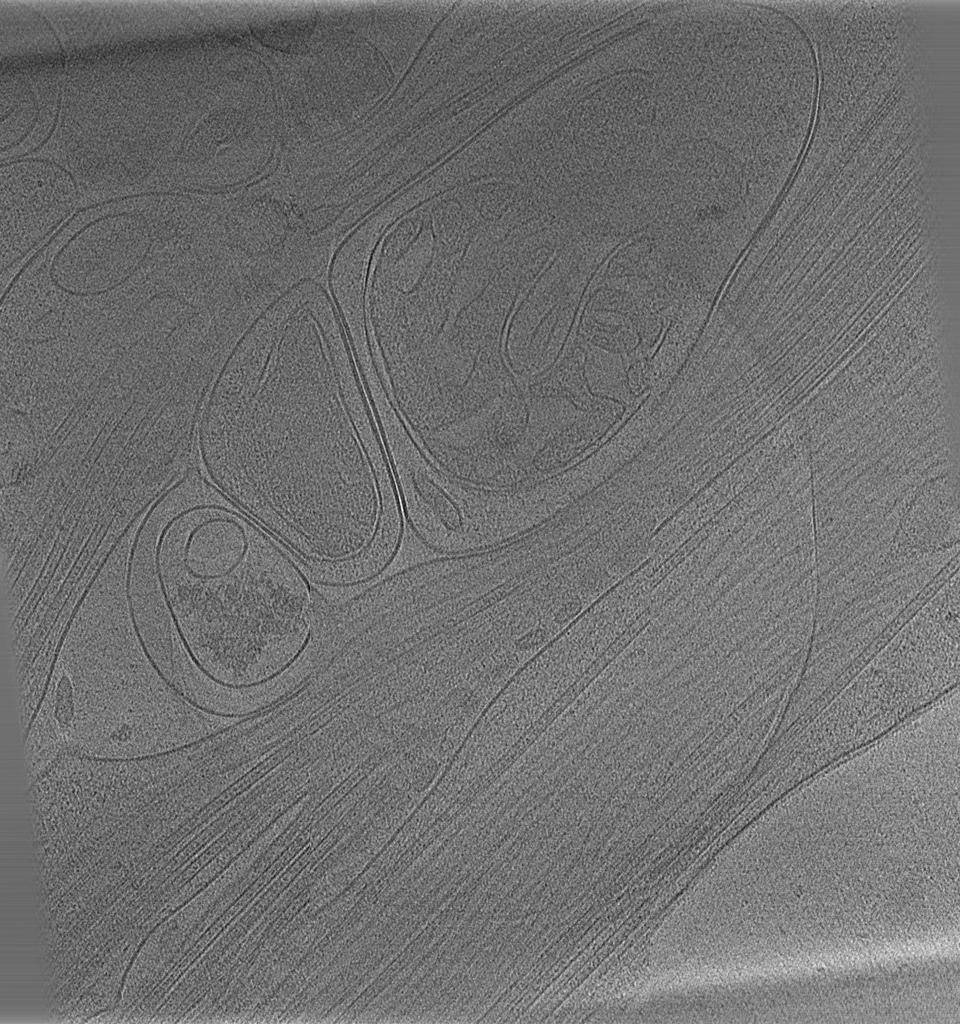

In [9]:
compare(rec_bern_downsampled, rec_pinv, cmap="gray", start_mode="horizontal", start_slider_pos=0.73, height=600)


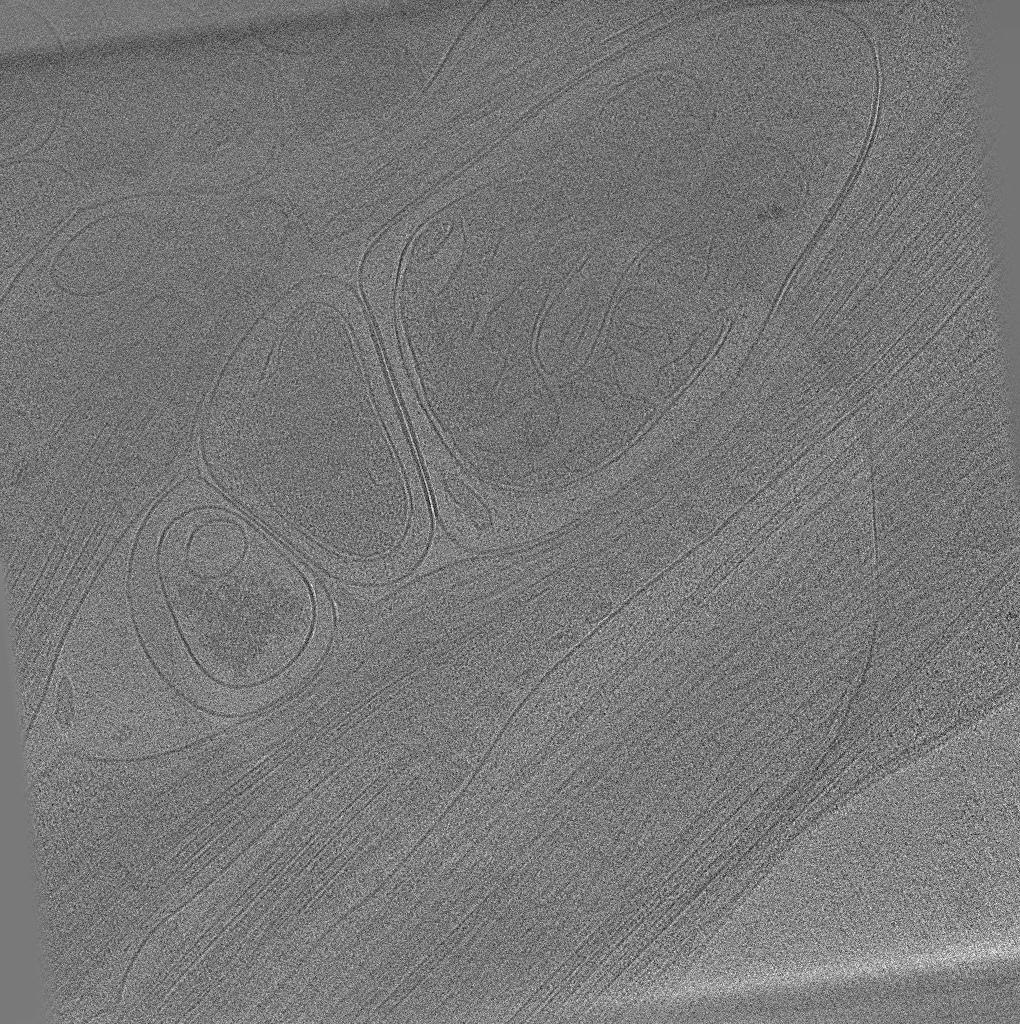
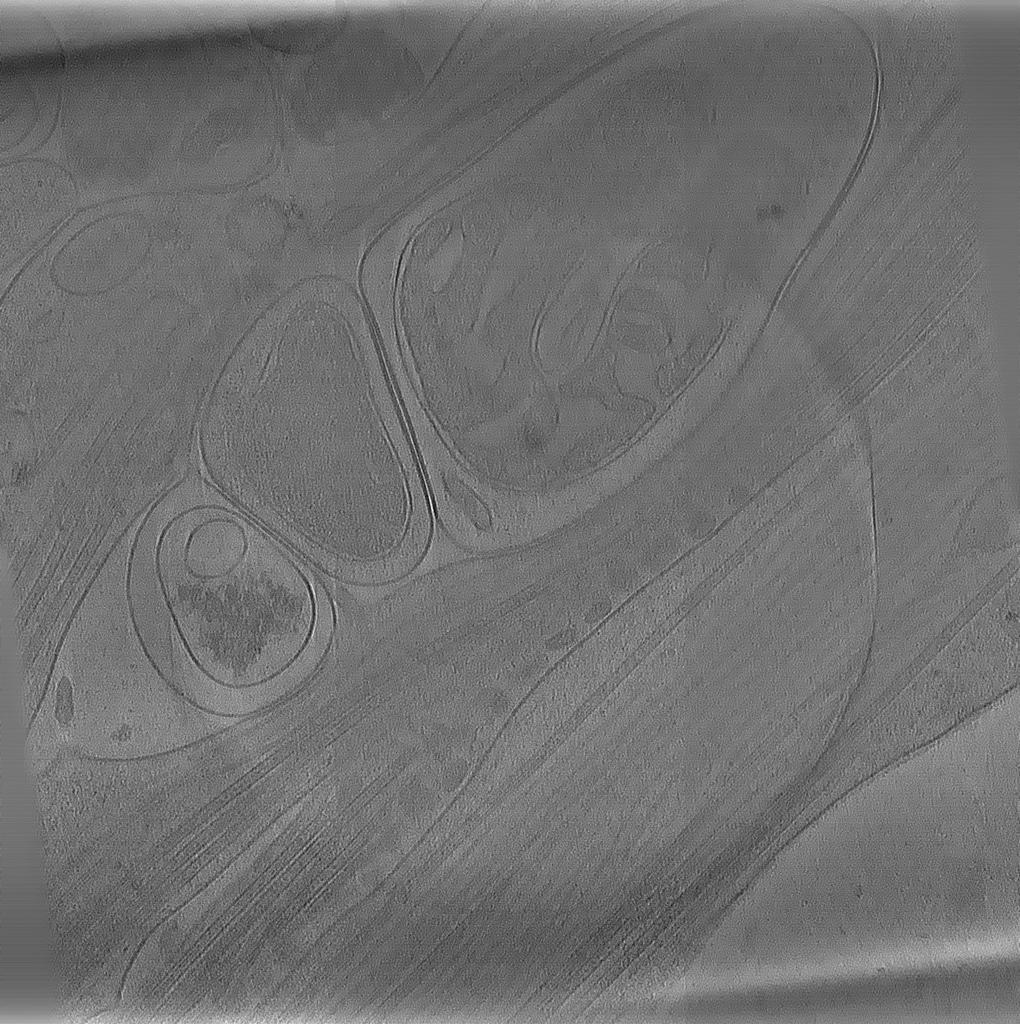

In [16]:
compare(rec_bern_downsampled, rec_tv, cmap="gray", start_mode="horizontal", start_slider_pos=0.73, height=600)